**Physics-Informed Neural Network (PINN) for DATAMSD mass-spring-damper data**

This notebook trains a PINN on the same `DATAMSD.xlsx` file used by `MSD_datamsd.ipynb`.

The model learns measured displacement and velocity while also penalizing violations of the mass-spring-damper structure:

`dx/dt = v`

`dv/dt + alpha*v + beta*x = f(t)`, where `alpha = c/m` and `beta = k/m`.

Because the dataset only contains `x` and `v` and does not include an external force column, this notebook uses a small latent force network `f(t)`. Set `USE_LATENT_FORCE = False` below if you want a strict unforced MSD model.

In [10]:
import importlib.util

if importlib.util.find_spec('torch') is None:
    raise ImportError(
        "PyTorch is required for this PINN notebook. Install it in the project venv with:\n"
        "    venv\\Scripts\\python.exe -m pip install torch\n"
        "Then restart the notebook kernel and run again."
    )

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(7)
np.random.seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


**Load and normalize the MSD data**

The original notebook uses `dt = 0.001` and `tf = 5`, giving 5000 samples. The first column is displacement `x`; the second column is velocity `v`.

In [11]:
data_path = Path('DATAMSD.xlsx')
if not data_path.exists():
    data_path = Path('Linear Systems') / 'DATAMSD.xlsx'

df = pd.read_excel(data_path)
data = df.values.astype(np.float32)

dt = 0.001
steps = data.shape[0]
t = (np.arange(steps, dtype=np.float32) * dt).reshape(-1, 1)
y = data

# Normalize time to [-1, 1] and states to zero mean / unit variance.
t_min = t.min()
t_max = t.max()
t_norm = 2.0 * (t - t_min) / (t_max - t_min) - 1.0

y_mean = y.mean(axis=0, keepdims=True)
y_std = y.std(axis=0, keepdims=True)
y_norm = (y - y_mean) / y_std

t_train = torch.tensor(t_norm, dtype=torch.float32, device=device, requires_grad=True)
y_train = torch.tensor(y_norm, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_std, dtype=torch.float32, device=device)
dt_norm_dt = torch.tensor(2.0 / (t_max - t_min), dtype=torch.float32, device=device)

print('Data shape:', data.shape)
print('x range:', data[:, 0].min(), data[:, 0].max())
print('v range:', data[:, 1].min(), data[:, 1].max())

Data shape: (5000, 2)
x range: -10.093296 11.6346035
v range: -86.99522 75.40054


**Define the PINN**

The state network predicts `[x(t), v(t)]`. Autograd computes derivatives with respect to time, and the loss combines data fitting with physics residuals.

In [12]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class MSD_PINN(nn.Module):
    def __init__(self, use_latent_force=True):
        super().__init__()
        self.state_net = MLP(1, 2, hidden=64, depth=4)
        self.force_net = MLP(1, 1, hidden=32, depth=2)
        self.use_latent_force = use_latent_force

        # Positive physical coefficients: alpha = c/m, beta = k/m.
        self.raw_alpha = nn.Parameter(torch.tensor(0.1))
        self.raw_beta = nn.Parameter(torch.tensor(1.0))
        self.softplus = nn.Softplus()

    def forward(self, t_in):
        y_hat_norm = self.state_net(t_in)
        y_hat = y_mean_t + y_std_t * y_hat_norm
        x_hat = y_hat[:, 0:1]
        v_hat = y_hat[:, 1:2]
        force_hat = self.force_net(t_in) if self.use_latent_force else torch.zeros_like(x_hat)
        alpha = self.softplus(self.raw_alpha)
        beta = self.softplus(self.raw_beta)
        return y_hat_norm, x_hat, v_hat, force_hat, alpha, beta


USE_LATENT_FORCE = True
model = MSD_PINN(use_latent_force=USE_LATENT_FORCE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

**Train the PINN**

For speed, the physics loss is evaluated on a random subset of time points each epoch. Increase `EPOCHS` if you want a tighter fit.

In [13]:
EPOCHS = 10000
PHYSICS_BATCH = 1024

lambda_data = 1.0
lambda_dx = 0.2
lambda_msd = 0.05
lambda_force = 1e-5 if USE_LATENT_FORCE else 0.0

history = []

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    y_hat_norm, _, _, _, alpha, beta = model(t_train)
    loss_data = torch.mean((y_hat_norm - y_train) ** 2)

    idx = torch.randint(0, steps, (min(PHYSICS_BATCH, steps),), device=device)
    t_phys = t_train[idx].clone().detach().requires_grad_(True)
    _, x_hat, v_hat, force_hat, alpha, beta = model(t_phys)

    dx_dt_norm = torch.autograd.grad(x_hat, t_phys, grad_outputs=torch.ones_like(x_hat), create_graph=True)[0]
    dv_dt_norm = torch.autograd.grad(v_hat, t_phys, grad_outputs=torch.ones_like(v_hat), create_graph=True)[0]
    dx_dt = dx_dt_norm * dt_norm_dt
    dv_dt = dv_dt_norm * dt_norm_dt

    residual_kinematics = dx_dt - v_hat
    residual_msd = dv_dt + alpha * v_hat + beta * x_hat - force_hat

    loss_dx = torch.mean(residual_kinematics ** 2)
    loss_msd = torch.mean(residual_msd ** 2)
    loss_force = torch.mean(force_hat ** 2)

    loss = (
        lambda_data * loss_data
        + lambda_dx * loss_dx
        + lambda_msd * loss_msd
        + lambda_force * loss_force
    )

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0 or epoch == 1:
        history.append([epoch, loss.item(), loss_data.item(), loss_dx.item(), loss_msd.item(), alpha.item(), beta.item()])
        print(
            f'Epoch {epoch:5d} | loss={loss.item():.6f} | data={loss_data.item():.6f} | '
            f'dx={loss_dx.item():.6f} | msd={loss_msd.item():.6f} | '
            f'alpha={alpha.item():.4f} | beta={beta.item():.4f}'
        )

Epoch     1 | loss=1.034100 | data=1.004258 | dx=0.099918 | msd=0.197181 | alpha=0.7444 | beta=1.3133
Epoch   500 | loss=1.001215 | data=1.001105 | dx=0.000316 | msd=0.000914 | alpha=0.7359 | beta=1.3031
Epoch  1000 | loss=0.999751 | data=0.999561 | dx=0.000482 | msd=0.001858 | alpha=0.7373 | beta=1.2228
Epoch  1500 | loss=0.995589 | data=0.994427 | dx=0.004731 | msd=0.004237 | alpha=0.7502 | beta=1.0296
Epoch  2000 | loss=0.989996 | data=0.988278 | dx=0.007683 | msd=0.003290 | alpha=0.8032 | beta=0.7517
Epoch  2500 | loss=0.980987 | data=0.977385 | dx=0.014883 | msd=0.011336 | alpha=0.9368 | beta=0.5783
Epoch  3000 | loss=0.971048 | data=0.967878 | dx=0.010102 | msd=0.020617 | alpha=1.1324 | beta=0.5016
Epoch  3500 | loss=0.973146 | data=0.960713 | dx=0.043485 | msd=0.070520 | alpha=1.3326 | beta=0.4893
Epoch  4000 | loss=0.959502 | data=0.954978 | dx=0.010291 | msd=0.042904 | alpha=1.5237 | beta=0.5215
Epoch  4500 | loss=0.951272 | data=0.949670 | dx=0.002779 | msd=0.014624 | alpha=1

**Evaluate and compare with measured data**

PINN RMSE x: 3.386130
PINN RMSE v: 30.207407
Learned alpha = c/m: 2.938597
Learned beta  = k/m: 1.342554


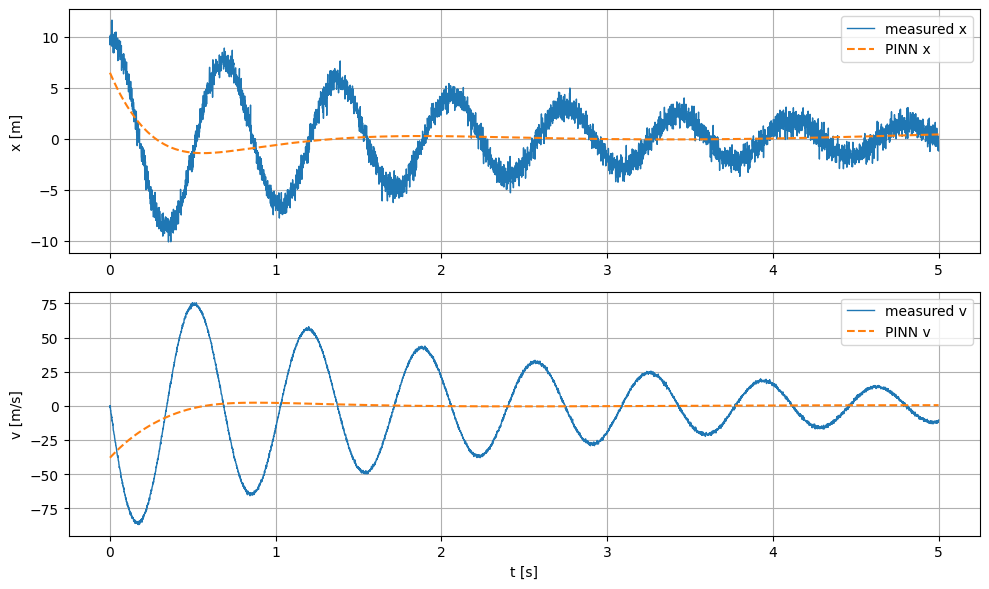

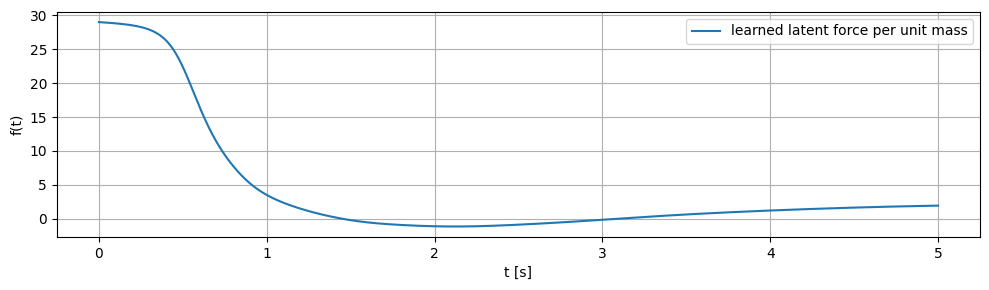

In [14]:
model.eval()
with torch.no_grad():
    y_hat_norm, x_hat, v_hat, force_hat, alpha, beta = model(torch.tensor(t_norm, dtype=torch.float32, device=device))
    y_pred = torch.cat([x_hat, v_hat], dim=1).cpu().numpy()
    force_pred = force_hat.cpu().numpy()

rmse = np.sqrt(np.mean((y - y_pred) ** 2, axis=0))
print(f'PINN RMSE x: {rmse[0]:.6f}')
print(f'PINN RMSE v: {rmse[1]:.6f}')
print(f'Learned alpha = c/m: {alpha.item():.6f}')
print(f'Learned beta  = k/m: {beta.item():.6f}')

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, y[:, 0], label='measured x', linewidth=1)
plt.plot(t, y_pred[:, 0], '--', label='PINN x', linewidth=1.5)
plt.grid()
plt.ylabel('x [m]')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, y[:, 1], label='measured v', linewidth=1)
plt.plot(t, y_pred[:, 1], '--', label='PINN v', linewidth=1.5)
plt.grid()
plt.ylabel('v [m/s]')
plt.xlabel('t [s]')
plt.legend()
plt.tight_layout()
plt.show()

if USE_LATENT_FORCE:
    plt.figure(figsize=(10, 3))
    plt.plot(t, force_pred, label='learned latent force per unit mass')
    plt.grid()
    plt.xlabel('t [s]')
    plt.ylabel('f(t)')
    plt.legend()
    plt.tight_layout()
    plt.show()

**Optional: train longer with LBFGS refinement**

Run this cell after Adam training if the curves need a closer match. It uses all data points and can be slower.

In [9]:
RUN_LBFGS = False

if RUN_LBFGS:
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=500, tolerance_grad=1e-7, tolerance_change=1e-9)

    def closure():
        lbfgs.zero_grad()
        y_hat_norm, x_hat, v_hat, force_hat, alpha, beta = model(t_train)
        loss_data = torch.mean((y_hat_norm - y_train) ** 2)

        dx_dt_norm = torch.autograd.grad(x_hat, t_train, grad_outputs=torch.ones_like(x_hat), create_graph=True)[0]
        dv_dt_norm = torch.autograd.grad(v_hat, t_train, grad_outputs=torch.ones_like(v_hat), create_graph=True)[0]
        dx_dt = dx_dt_norm * dt_norm_dt
        dv_dt = dv_dt_norm * dt_norm_dt

        loss_dx = torch.mean((dx_dt - v_hat) ** 2)
        loss_msd = torch.mean((dv_dt + alpha * v_hat + beta * x_hat - force_hat) ** 2)
        loss_force = torch.mean(force_hat ** 2)
        loss = lambda_data * loss_data + lambda_dx * loss_dx + lambda_msd * loss_msd + lambda_force * loss_force
        loss.backward()
        return loss

    final_loss = lbfgs.step(closure)
    print('Final LBFGS loss:', float(final_loss))